# Exercises in linear regression

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import kagglehub
import os

import statsmodels.api as sm
from sklearn import linear_model
from sklearn.model_selection import train_test_split
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error, root_mean_squared_error

energy_efficiency_file_path = './EnergyEfficiency.csv'
energy_data = pd.read_csv(energy_efficiency_file_path)
energy_data

c:\Users\nikol\AppData\Local\Python\pythoncore-3.14-64\Lib\site-packages\tqdm\auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


,RelativeCompactness,SurfaceArea,WallArea,RoofArea,OverallHeight,Orientation,GlazingArea,GlazingAreaDistribution,HeatingLoad,CoolingLoad
0,0.98,514.5,294.0,110.25,7.0,2,0.0,0,15.55,21.33
1,0.98,514.5,294.0,110.25,7.0,3,0.0,0,15.55,21.33
2,0.98,514.5,294.0,110.25,7.0,4,0.0,0,15.55,21.33
3,0.98,514.5,294.0,110.25,7.0,5,0.0,0,15.55,21.33
4,0.90,563.5,318.5,122.50,7.0,2,0.0,0,20.84,28.28
...,...,...,...,...,...,...,...,...,...,...
763,0.64,784.0,343.0,220.50,3.5,5,0.4,5,17.88,21.40
764,0.62,808.5,367.5,220.50,3.5,2,0.4,5,16.54,16.88
765,0.62,808.5,367.5,220.50,3.5,3,0.4,5,16.44,17.11
766,0.62,808.5,367.5,220.50,3.5,4,0.4,5,16.48,16.61


## Exercise 1

Load in the "EnergyEfficiency.csv" data (on Moodle). It is data about energy efficiency of buildings, more specifically it is about predicting the heating load and cooling load of building based on a set of features about the buildings. It is retrieved from UCI Machine Learning Repository: [Energy efficiency](https://archive.ics.uci.edu/dataset/242/energy+efficiency).

Answer the following questions:

1. Do a visualization of the relationship/correlation between the variables `SurfaceArea` and `HeatingLoad`, with `HeatingLoad` as the dependent variable (y variable).

-0.6581202267776216
             SurfaceArea  HeatingLoad
SurfaceArea      1.00000     -0.65812
HeatingLoad     -0.65812      1.00000


Text(0.5, 1.0, 'Visualization of correlation between SurfaceArea and HeatingLoad')

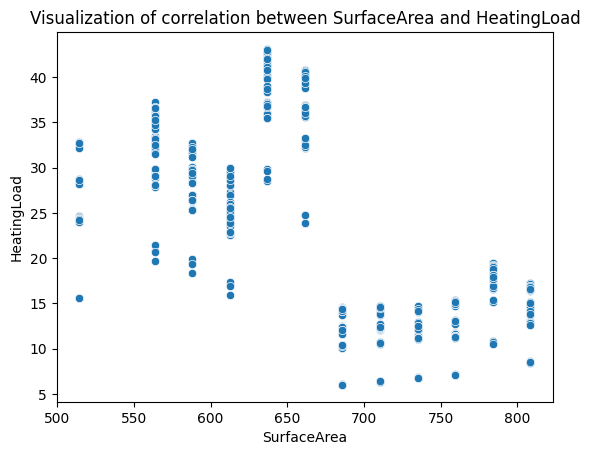

In [2]:
# Numbers
correlation = energy_data['SurfaceArea'].corr(energy_data['HeatingLoad'])
print(correlation)

correlation = energy_data[['SurfaceArea', 'HeatingLoad']].corr()
print(correlation)

# Visual
sns.scatterplot(x='SurfaceArea', y='HeatingLoad', data=energy_data)
plt.title('Visualization of correlation between SurfaceArea and HeatingLoad')

2. Is there a correlation between `SurfaceArea` and `HeatingLoad`? If so, what is the strength of it, and is it statistically significant? Does this make sense to you, if `SurfaceArea` is the surface area of a building and the `HeatingLoad` is how much energy it takes to heat up the building?

We have a correlation coefficient on -0.6581. There is a negative correlation between `SurfaceArea` and `HeatingLoad`. This is a moderate negative correlation, with with just this information is abit counterintuitive.

3. Add `hue = "OverallHeight"` to the scatterplot you did as an answer to question 1. Assuming that `OeverallHeight` represent the height of the building, does it change your answer to the last question of 2?

When you look at it, with the buildings separated in height the correlations makes more sense. From the graf you can see both have a posetive correlation, which makes more sense. The overall negative correlation happened earlier because taller buildings (which need more heating) tend to have smaller surface areas relative to their volume.

Text(0.5, 1.0, 'Visualization of correlation between SurfaceArea and HeatingLoad (with hue)')

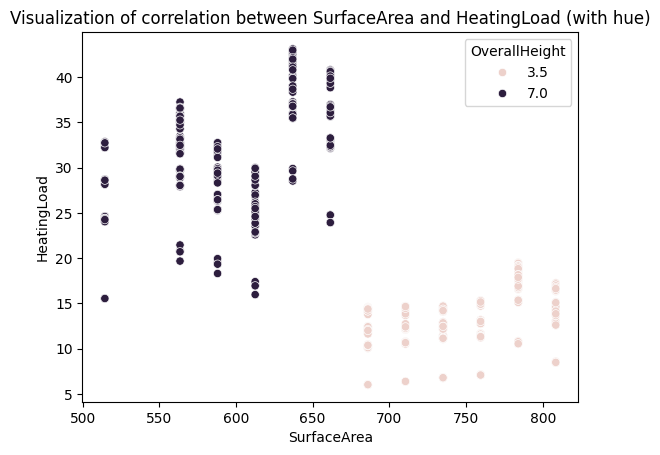

In [3]:
sns.scatterplot(x='SurfaceArea', y='HeatingLoad', data=energy_data, hue='OverallHeight')
plt.title('Visualization of correlation between SurfaceArea and HeatingLoad (with hue)')

4. Train a simple linear regression model with `SurfaceArea` as independent variable (x) and `HeatingLoad` as dependent variable (y).

In [4]:
X = energy_data['SurfaceArea']
X = sm.add_constant(X)

y = energy_data['HeatingLoad']

linreg_model = sm.OLS(y, X).fit()
linreg_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            HeatingLoad   R-squared:                       0.433
Model:                            OLS   Adj. R-squared:                  0.432
Method:                 Least Squares   F-statistic:                     585.3
Date:                Wed, 11 Mar 2026   Prob (F-statistic):           1.69e-96
Time:                        12:41:09   Log-Likelihood:                -2646.6
No. Observations:                 768   AIC:                             5297.
Df Residuals:                     766   BIC:                             5306.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          72.9454      2.111     34.554      0.000      68.801      77.090
SurfaceArea    -0.0754      0.003    -24.192      0.000      -0.082      -0.069
==============================================================================
Omnibus:                       37.973   Durbin-Watson:                   0.321
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               42.851
Skew:                           0.576   Prob(JB):                     4.95e-10
Kurtosis:                       2.890   Cond. No.                     5.21e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 5.21e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

5. What does the model say about the change in `HeatingLoad` when the `SurfaceArea` goes up by 1 unit?

In [5]:
coefficient = linreg_model.params['SurfaceArea']
print(f"When SurfaceArea increases by 1 unit, HeatingLoad changes by: {coefficient}")

When SurfaceArea increases by 1 unit, HeatingLoad changes by: -0.07538715748537175


Looking at the coefficient, when SurfaceArea goes up by 1 unit, HeatingLoad changes by -0.075. This is a negative relationship.

6. Add the linear regression line to a scatterplot of `SurfaceArea` and `HeatingLoad`.

Text(0.5, 1.0, 'Linear regression plot for SurfaceArea and HeatingLoad')

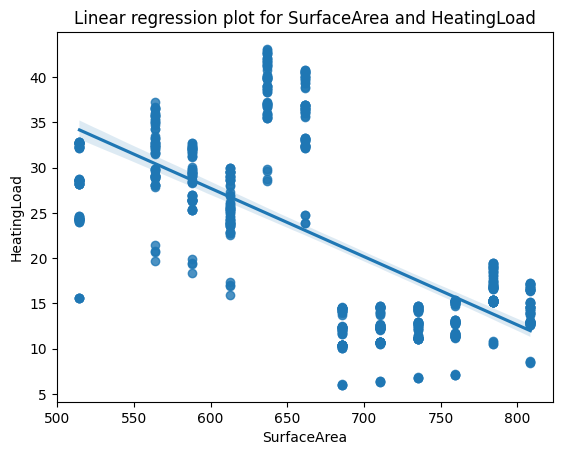

In [6]:
sns.regplot(x='SurfaceArea', y='HeatingLoad', data=energy_data)
plt.title('Linear regression plot for SurfaceArea and HeatingLoad')

7. Evaluate how good your simple linear regression model is. Hint: Chose one or several measures to evaluate your model.

In [7]:
y_pred = linreg_model.predict(X)
print("R²:", r2_score(y, y_pred))
print("RMSE:", root_mean_squared_error(y, y_pred))
print("MAE:", mean_absolute_error(y, y_pred))

R²: 0.43312223289382823
RMSE: 7.592090475900786
MAE: 6.002338517195692


An R-squared of 0.433 means that Surface Area explains about 43% of the variation in Heating Load. This shows a moderate connection; while Surface Area is important, other factors not included in this model also affect the heating load.

8. Subset your data such that you only have houses with "OverallHeight=7" and train a new simple linear regression model with `SurfaceArea` as independent variable and `HeatingLoad` as dependent variable. How good is this model compared to the on trained on the full dataset?

In [8]:
subset_data = energy_data[energy_data['OverallHeight'] == 7]

X = subset_data['SurfaceArea']
X = sm.add_constant(X)

y = subset_data['HeatingLoad']

linreg_model = sm.OLS(y, X).fit()
linreg_model.summary()


<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            HeatingLoad   R-squared:                       0.215
Model:                            OLS   Adj. R-squared:                  0.213
Method:                 Least Squares   F-statistic:                     104.8
Date:                Wed, 11 Mar 2026   Prob (F-statistic):           6.84e-22
Time:                        12:41:09   Log-Likelihood:                -1183.0
No. Observations:                 384   AIC:                             2370.
Df Residuals:                     382   BIC:                             2378.
Df Model:                           1                                         
Covariance Type:            nonrobust                                         
===============================================================================
                  coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------
const          -2.7676      3.337     -0.829      0.407      -9.328       3.793
SurfaceArea     0.0571      0.006     10.236      0.000       0.046       0.068
==============================================================================
Omnibus:                       15.054   Durbin-Watson:                   0.315
Prob(Omnibus):                  0.001   Jarque-Bera (JB):               15.752
Skew:                          -0.474   Prob(JB):                     0.000380
Kurtosis:                       2.706   Cond. No.                     7.40e+03
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 7.4e+03. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

## Exercise 2

In this exercise, we will continue from Exercise 1 and keep using the "EnergyEfficiency.csv" data (on Moodle).

Answer the following questions:
1. Train a multiple linear regression model for `HeatingLoad` using at least two other variables from the dataset as feature variables.

In [14]:
X = energy_data[['SurfaceArea', 'WallArea', 'RoofArea', 'RelativeCompactness']]
X = sm.add_constant(X)
y = energy_data['HeatingLoad']

multi_model = sm.OLS(y, X).fit()
multi_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:            HeatingLoad   R-squared:                       0.826
Model:                            OLS   Adj. R-squared:                  0.825
Method:                 Least Squares   F-statistic:                     1206.
Date:                Wed, 11 Mar 2026   Prob (F-statistic):          3.27e-289
Time:                        12:54:05   Log-Likelihood:                -2193.8
No. Observations:                 768   AIC:                             4396.
Df Residuals:                     764   BIC:                             4414.
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
=======================================================================================
                          coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------------
const                 266.5414     17.936     14.861      0.000     231.332     301.751
SurfaceArea            -0.1959      0.011    -17.160      0.000      -0.218      -0.174
WallArea                0.0703      0.004     18.305      0.000       0.063       0.078
RoofArea               -0.1331      0.005    -28.694      0.000      -0.142      -0.124
RelativeCompactness  -145.9437     11.381    -12.823      0.000    -168.286    -123.602
==============================================================================
Omnibus:                       25.602   Durbin-Watson:                   0.409
Prob(Omnibus):                  0.000   Jarque-Bera (JB):               59.314
Skew:                          -0.093   Prob(JB):                     1.32e-13
Kurtosis:                       4.349   Cond. No.                     1.80e+16
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The smallest eigenvalue is 1.4e-24. This might indicate that there are
strong multicollinearity problems or that the design matrix is singular.
"""

2. Evaluate our multiple linear regression model and compare its performance to your simple linear regression model. Did you manage to make a better model?

In [15]:
y_pred_multi = multi_model.predict(X)

print("Multiple Linear Regression:")
print("R²:", r2_score(y, y_pred_multi))
print("RMSE:", root_mean_squared_error(y, y_pred_multi))
print("MAE:", mean_absolute_error(y, y_pred_multi))

Multiple Linear Regression:
R²: 0.8256616079819805
RMSE: 4.210301345149499
MAE: 3.11502252325346


The R-squared value is 0.825 for the multiple linear regression model, which is significantly higher than the R-squared of 0.433 for the simple linear regression model. This indicates that the multiple linear regression model explains a much larger portion of the variance in Heating Load compared to the simple model, suggesting that it is a better fit for the data.

## Exercise 3

In this exercise, we will use the Ames dataset from the multiple linear regression notebook.

Answer the following questions:

In [17]:
# Load the Ames dataset
ames_data = pd.read_csv('AmesHousing.csv')

1. Can you train a linear regression model to achieve a lower RMSE than the models we saw in the multiple linear regression notebook?

In [23]:
# Features - picking strong predictors
X = ames_data[['Gr Liv Area', 'Overall Qual', 'Year Built', 'Garage Area', 'Total Bsmt SF']].fillna(0)
y = ames_data['SalePrice']

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

X_train_sm = sm.add_constant(X_train)
X_test_sm = sm.add_constant(X_test)

ames_model = sm.OLS(y_train, X_train_sm).fit()
ames_model.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:              SalePrice   R-squared:                       0.783
Model:                            OLS   Adj. R-squared:                  0.782
Method:                 Least Squares   F-statistic:                     1683.
Date:                Wed, 11 Mar 2026   Prob (F-statistic):               0.00
Time:                        13:01:18   Log-Likelihood:                -27915.
No. Observations:                2344   AIC:                         5.584e+04
Df Residuals:                    2338   BIC:                         5.588e+04
Df Model:                           5                                         
Covariance Type:            nonrobust                                         
=================================================================================
                    coef    std err          t      P>|t|      [0.025      0.975]
---------------------------------------------------------------------------------
const         -7.755e+05   6.05e+04    -12.820      0.000   -8.94e+05   -6.57e+05
Gr Liv Area      50.3832      1.913     26.336      0.000      46.632      54.135
Overall Qual   2.101e+04    820.352     25.615      0.000    1.94e+04    2.26e+04
Year Built      355.9154     31.803     11.191      0.000     293.551     418.280
Garage Area      46.8566      4.568     10.258      0.000      37.899      55.814
Total Bsmt SF    26.8944      2.111     12.739      0.000      22.754      31.035
==============================================================================
Omnibus:                      811.162   Durbin-Watson:                   1.963
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            87849.027
Skew:                          -0.617   Prob(JB):                         0.00
Kurtosis:                      32.966   Cond. No.                     2.24e+05
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 2.24e+05. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

2. Can you train a linear regression model to achieve a higher R-squared than the final model in the multiple linear regression notebook?

In [24]:
y_pred_ames = ames_model.predict(X_test_sm)

print("R²:", r2_score(y_test, y_pred_ames))
print("RMSE:", root_mean_squared_error(y_test, y_pred_ames))
print("MAE:", mean_absolute_error(y_test, y_pred_ames))

R²: 0.8002198854113586
RMSE: 40021.82709918023
MAE: 25554.686636006758


The model achieves an R² of 0.80 and an RMSE of 40021 on the test data. Compared to the simple model from Exercise 1 (R²=0.43, RMSE=7.59), this model performs significantly better because we are using multiple strong predictors like overall quality and living area. Note that the RMSE is large because SalePrice is in dollars, so an average error of 40,000 dollars.



3. Do your models satisfy the assumptions of linear regression?

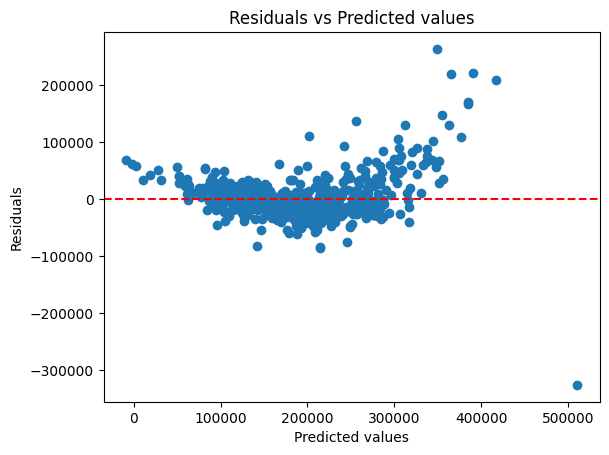

In [25]:
# Check assumptions - plot residuals vs predicted values
residuals = y_test - y_pred_ames

plt.scatter(y_pred_ames, residuals)
plt.axhline(y=0, color='r', linestyle='--')
plt.xlabel('Predicted values')
plt.ylabel('Residuals')
plt.title('Residuals vs Predicted values')
plt.show()

Looking at the residuals vs predicted values plot, we can see that the residuals are randomly scattered around the horizontal line at 0, which suggests that the assumptions of linear regression are satisfied. There is no clear pattern in the residuals, indicating that the model is appropriate for the data.